In [5]:
# Cell 1: Install all dependencies
!pip install nibabel monai scikit-learn matplotlib seaborn tqdm torch torchvision pydicom
!pip install git+https://github.com/MIC-DKFZ/HD-BET

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 99.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 115.0 MB/s eta 0:00:00
  Cloning https://github.com/MIC-DKFZ/HD-BET to /tmp/pip-req-build-u00scwmx
  Running command git clone --filter=blob:none --quiet https://github.com/MIC-DKFZ/HD-BET /tmp/pip-req-build-u00scwmx
  Resolved https://github.com/MIC-DKFZ/HD-BET to commit 678e44d546a84de0f2a7fc245f176b82b7d912fd
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.9/212.9 kB 19.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━

In [6]:
# Cell 2: Mount Drive and setup directories
from google.colab import drive
drive.mount('/content/drive')

import os

ZIP_PATH   = '/content/drive/MyDrive/MRI.zip'
EXTRACT_TO = '/content/dataset'
OUTPUT_DIR = '/content/preprocessed'

os.makedirs(EXTRACT_TO, exist_ok=True)
for split in ['train', 'val', 'test']:
    for cls in ['CN', 'MCI', 'AD']:
        os.makedirs(f'{OUTPUT_DIR}/{split}/{cls}', exist_ok=True)

print("✅ Directories created")

Mounted at /content/drive
✅ Directories created


In [7]:
# Cell 3: Extract dataset ZIP
import zipfile

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_TO)
    print(f"✅ Extracted {len(z.namelist())} files")

✅ Extracted 64011 files


In [8]:
# Cell 4: Load CSV metadata and match DICOM folders
import pandas as pd
import os

CSV_PATH = '/content/drive/MyDrive/MRI_metadata.csv'
df = pd.read_csv(CSV_PATH)
DATASET_MRI_DIR = '/content/dataset/MRI'

# Index all DICOM folders by ImageID
all_dcm_folders = {}
for subject_dir in os.listdir(DATASET_MRI_DIR):
    subject_path = os.path.join(DATASET_MRI_DIR, subject_dir)
    if not os.path.isdir(subject_path): continue
    for scan_type in os.listdir(subject_path):
        scan_path = os.path.join(subject_path, scan_type)
        if not os.path.isdir(scan_path): continue
        for date_dir in os.listdir(scan_path):
            date_path = os.path.join(scan_path, date_dir)
            if not os.path.isdir(date_path): continue
            for image_id in os.listdir(date_path):
                image_path = os.path.join(date_path, image_id)
                if os.path.isdir(image_path):
                    all_dcm_folders[image_id] = image_path

def find_dicom_folder(image_id):
    return all_dcm_folders.get(image_id, None)

df['folder_path'] = df['ImageID'].apply(find_dicom_folder)
matched = df.dropna(subset=['folder_path']).copy()
print(f"✅ Matched: {len(matched)} total scans")
print(matched['Group'].value_counts())

✅ Matched: 383 total scans
Group
MCI    180
CN     121
AD      82
Name: count, dtype: int64


In [9]:
# Cell 5: Subject-level train/val/test split
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=42)
train_idx, temp_idx = next(gss.split(matched, matched['Group'], groups=matched['Subject']))
train_df = matched.iloc[train_idx]
temp_df  = matched.iloc[temp_idx]

gss_temp = GroupShuffleSplit(n_splits=1, train_size=0.50, random_state=42)
val_idx, test_idx = next(gss_temp.split(temp_df, temp_df['Group'], groups=temp_df['Subject']))
val_df  = temp_df.iloc[val_idx]
test_df = temp_df.iloc[test_idx]

print(f"Train scans : {len(train_df)}")
print(f"Val scans   : {len(val_df)}")
print(f"Test scans  : {len(test_df)}")

# Verify no subject leakage between splits
train_subjects = set(train_df['Subject'])
val_subjects   = set(val_df['Subject'])
test_subjects  = set(test_df['Subject'])
assert len(train_subjects & val_subjects) == 0, "❌ Subject leakage: train/val"
assert len(train_subjects & test_subjects) == 0, "❌ Subject leakage: train/test"
assert len(val_subjects & test_subjects) == 0, "❌ Subject leakage: val/test"
print("✅ No subject leakage between splits")

Train scans : 263
Val scans   : 61
Test scans  : 59
✅ No subject leakage between splits


In [10]:
# Cell 6: Convert all DICOM folders to NIfTI first (batch, no HD-BET yet)
import os
import numpy as np
import nibabel as nib
import pydicom
import glob
import torch
import torch.nn.functional as F
import subprocess
from tqdm import tqdm

TARGET_SHAPE = (128, 128, 128)
NIFTI_DIR    = '/content/nifti_raw'       # raw NIfTI before skull stripping
STRIPPED_DIR = '/content/nifti_stripped'  # HD-BET output
os.makedirs(NIFTI_DIR,    exist_ok=True)
os.makedirs(STRIPPED_DIR, exist_ok=True)

def load_dicom_volume(folder_path):
    all_files = sorted(glob.glob(f'{folder_path}/**/*', recursive=True))
    dcm_files = [f for f in all_files if os.path.isfile(f)]
    if not dcm_files:
        raise ValueError(f"No files in {folder_path}")

    slices, positions = [], []
    for f in dcm_files:
        try:
            ds = pydicom.dcmread(f, force=True)
            if not hasattr(ds, "pixel_array"): continue
            arr = ds.pixel_array.astype(np.float32)
            if arr.std() < 5: continue
            arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
            slices.append(arr)
            if hasattr(ds, "InstanceNumber"):
                positions.append(int(ds.InstanceNumber))
            elif hasattr(ds, "ImagePositionPatient"):
                positions.append(float(ds.ImagePositionPatient[2]))
            else:
                positions.append(len(positions))
        except:
            continue

    if len(slices) < 10:
        raise ValueError(f"Too few slices: {len(slices)}")

    sorted_idx = np.argsort(np.array(positions))
    slices     = [slices[i] for i in sorted_idx]
    min_h      = min(s.shape[0] for s in slices)
    min_w      = min(s.shape[1] for s in slices)
    slices     = [s[:min_h, :min_w] for s in slices]
    return np.stack(slices, axis=-1)


print("⏳ Step 1: Converting DICOM → NIfTI for all subjects...")
all_rows   = pd.concat([train_df, val_df, test_df]).drop_duplicates(subset='ImageID')
ok, failed = 0, []

for _, row in tqdm(all_rows.iterrows(), total=len(all_rows), desc="DICOM→NIfTI"):
    out_path = f"{NIFTI_DIR}/{row['ImageID']}.nii.gz"
    if os.path.exists(out_path):   # skip if already done
        ok += 1
        continue
    try:
        vol     = load_dicom_volume(row['folder_path'])
        vol     = np.clip(vol, np.percentile(vol, 1), np.percentile(vol, 99))
        nib.save(nib.Nifti1Image(vol, affine=np.eye(4)), out_path)
        ok += 1
    except Exception as e:
        failed.append((row['ImageID'], str(e)))

print(f"✅ NIfTI saved: {ok}  ❌ Failed: {len(failed)}")
if failed:
    print("Failed:", failed[:5])

⏳ Step 1: Converting DICOM → NIfTI for all subjects...


DICOM→NIfTI: 100%|██████████| 383/383 [10:26<00:00,  1.64s/it]

✅ NIfTI saved: 383  ❌ Failed: 0


In [11]:
# Cell 7: Run HD-BET once on entire folder — much faster than per-subject
print("⏳ Step 2: Running HD-BET in batch mode...")

# HD-BET batch: point it at the input folder, outputs go to STRIPPED_DIR
command = f"hd-bet -i {NIFTI_DIR} -o {STRIPPED_DIR} -device cuda:0 --disable_tta"
result  = subprocess.run(command, shell=True, capture_output=True, text=True)

if result.returncode != 0:
    print(f"❌ HD-BET batch failed:\n{result.stderr[:500]}")
else:
    stripped_files = [f for f in os.listdir(STRIPPED_DIR) if f.endswith('.nii.gz') and 'mask' not in f]
    print(f"✅ HD-BET batch complete! Stripped files: {len(stripped_files)}")

⏳ Step 2: Running HD-BET in batch mode...
✅ HD-BET batch complete! Stripped files: 383


In [12]:
# Cell 8: Normalize + resize stripped NIfTIs → save as .npy per split
print("⏳ Step 3: Saving preprocessed splits...")

def postprocess_and_save(split_df, split_name):
    ok, skipped, errors = 0, 0, []

    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=split_name):
        save_path = f"{OUTPUT_DIR}/{split_name}/{row['Group']}/{row['ImageID']}.npy"

        if os.path.exists(save_path):   # skip already done
            skipped += 1
            ok += 1
            continue

        # Try stripped version first, fall back to raw NIfTI
        stripped_path = f"{STRIPPED_DIR}/{row['ImageID']}.nii.gz"
        raw_path      = f"{NIFTI_DIR}/{row['ImageID']}.nii.gz"

        try:
            if os.path.exists(stripped_path):
                volume = nib.load(stripped_path).get_fdata().astype(np.float32)
            elif os.path.exists(raw_path):
                print(f"  ⚠️ No stripped file for {row['ImageID']}, using raw NIfTI")
                volume = nib.load(raw_path).get_fdata().astype(np.float32)
            else:
                errors.append((row['ImageID'], 'no NIfTI found'))
                continue

            # Z-score normalize within brain mask
            brain_mask = volume > 0
            if brain_mask.sum() > 0:
                mean, std = volume[brain_mask].mean(), volume[brain_mask].std()
                if std > 1e-6:
                    volume[brain_mask] = (volume[brain_mask] - mean) / std

            # Resize to target shape
            tensor  = torch.tensor(volume).unsqueeze(0).unsqueeze(0)
            resized = F.interpolate(tensor, size=TARGET_SHAPE, mode='trilinear', align_corners=False)
            volume  = resized.squeeze().numpy()

            if volume.max() == 0:
                errors.append((row['ImageID'], 'black image'))
                continue

            np.save(save_path, volume)
            ok += 1

        except Exception as e:
            errors.append((row['ImageID'], str(e)))

    print(f"  ✅ Saved: {ok}  ⏭ Skipped: {skipped}  ❌ Errors: {len(errors)}")
    if errors:
        print(f"  Errors: {errors[:5]}")

postprocess_and_save(train_df, 'train')
postprocess_and_save(val_df,   'val')
postprocess_and_save(test_df,  'test')

print("\n📦 Zipping to Google Drive...")
!zip -r /content/drive/MyDrive/MRI_Preprocessed_Final.zip /content/preprocessed
print("✅ All done!")

⏳ Step 3: Saving preprocessed splits...


train: 100%|██████████| 263/263 [02:24<00:00,  1.82it/s]


  ✅ Saved: 263  ⏭ Skipped: 0  ❌ Errors: 0


val: 100%|██████████| 61/61 [00:33<00:00,  1.81it/s]


  ✅ Saved: 61  ⏭ Skipped: 0  ❌ Errors: 0


test: 100%|██████████| 59/59 [00:32<00:00,  1.84it/s]


  ✅ Saved: 59  ⏭ Skipped: 0  ❌ Errors: 0

📦 Zipping to Google Drive...
updating: content/preprocessed/ (stored 0%)
updating: content/preprocessed/test/ (stored 0%)
updating: content/preprocessed/test/MCI/ (stored 0%)
updating: content/preprocessed/test/MCI/I8248.npy (deflated 88%)
updating: content/preprocessed/test/MCI/I36695.npy (deflated 88%)
updating: content/preprocessed/test/MCI/I45610.npy (deflated 89%)
updating: content/preprocessed/test/MCI/I8249.npy (deflated 88%)
updating: content/preprocessed/test/MCI/I36803.npy (deflated 87%)
updating: content/preprocessed/test/MCI/I17512.npy (deflated 91%)
updating: content/preprocessed/test/MCI/I36702.npy (deflated 90%)
updating: content/preprocessed/test/MCI/I17420.npy (deflated 89%)
updating: content/preprocessed/test/MCI/I36802.npy (deflated 87%)
updating: content/preprocessed/test/MCI/I36696.npy (deflated 88%)
updating: content/preprocessed/test/MCI/I17419.npy (deflated 89%)
updating: content/preprocessed/test/MCI/I16848.npy (deflate

In [15]:
# =============================================================================
# CELL 9 — 3D Dataset with MONAI Augmentations
# Drop-in replacement for MRIDataset25D
# Reads the same .npy files from OUTPUT_DIR (no preprocessing changes needed)
# =============================================================================
#3D Dataset with MONAI Augmentations
# Drop-in replacement for MRIDataset25D
# Reads the same .npy files from OUTPUT_DIR (no preprocessing changes needed)
# =============================================================================

import os
import numpy as np
import torch
from torch.utils.data import Dataset
from monai.transforms import (
    Compose, RandRotate, RandFlip,
    RandScaleIntensity, RandGaussianNoise, EnsureType
)

class MRIDataset3D(Dataset):
    """
    Loads preprocessed .npy volumes (128, 128, 128) and returns them as
    [1, 128, 128, 128] float32 tensors — ready for MONAI 3D CNNs.

    Replaces MRIDataset25D entirely. No changes to OUTPUT_DIR or .npy files.

    Augmentations used (3D-safe):
      - RandRotate       : ±15° across all 3 axes (0.26 rad)
      - RandFlip         : left-right axis only (brain LR symmetry is safe)
      - RandScaleIntensity: ±15% contrast scale
      - RandGaussianNoise: σ=0.02 additive noise
    """
    def __init__(self, root_dir, classes, augment=False):
        self.samples      = []
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.augment      = augment

        # All MONAI transforms operate on (C, H, W, D) shaped inputs
        # EnsureType at the end guarantees a float32 torch.Tensor output
        self.aug_transforms = Compose([
            RandRotate(
                range_x=0.26, range_y=0.26, range_z=0.26,  # ±15° in radians
                prob=0.5,
                keep_size=True,
                padding_mode='zeros'
            ),
            RandFlip(spatial_axis=0, prob=0.5),             # L-R flip only
            RandScaleIntensity(factors=0.15, prob=0.5),     # replaces brightness/contrast
            RandGaussianNoise(prob=0.5, mean=0.0, std=0.02),
            EnsureType(data_type='tensor', dtype=torch.float32),
        ])

        for cls in classes:
            folder = os.path.join(root_dir, cls)
            if not os.path.exists(folder):
                continue
            for f in sorted(os.listdir(folder)):
                if f.endswith('.npy'):
                    self.samples.append(
                        (os.path.join(folder, f), self.class_to_idx[cls])
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        vol = np.load(path).astype(np.float32)  # (128, 128, 128)

        # Add channel dim → (1, 128, 128, 128)
        # This single channel is required by MONAI 3D CNNs (n_input_channels=1)
        vol = vol[np.newaxis, ...]

        if self.augment:
            vol = self.aug_transforms(vol)

        tensor = vol if isinstance(vol, torch.Tensor) else torch.tensor(vol, dtype=torch.float32)
        return tensor, torch.tensor(label, dtype=torch.long)


print("✅ MRIDataset3D defined")
print("   Output tensor shape : [1, 128, 128, 128]")
print("   Augmentations (train): RandRotate | RandFlip | RandScaleIntensity | RandGaussianNoise")

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


✅ MRIDataset3D defined
   Output tensor shape : [1, 128, 128, 128]
   Augmentations (train): RandRotate | RandFlip | RandScaleIntensity | RandGaussianNoise


In [17]:
# =============================================================================
# CELL 10 — MONAI ResNet10 (3D) + AMP Training + Shared Utilities
# Replaces get_resnet_model(), train_model(), evaluate_model()
# =============================================================================
#MONAI ResNet10 (3D) + AMP Training + Shared Utilities
# Replaces get_resnet_model(), train_model(), evaluate_model()
# =============================================================================

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import copy
from torch.amp import autocast, GradScaler
from torch.utils.data import DataLoader
from monai.networks.nets import resnet10
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    balanced_accuracy_score, roc_auc_score,
    f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import joblib

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if device.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


# ─── Model factory ────────────────────────────────────────────────────────────

def get_3d_model(num_classes):
    """
    MONAI ResNet10 with spatial_dims=3.

    Architecture summary:
      Input  : [B, 1, 128, 128, 128]
      Output : [B, num_classes]
      Feature dim before FC : 512

    num_classes:
      2 → binary   (CN vs AD)
      3 → multiclass (CN vs MCI vs AD)

    Dropout(0.5) is injected before the final Linear layer.
    This is the most important regularizer for a < 300 sample dataset.
    """
    model = resnet10(
        spatial_dims=3,
        n_input_channels=1,
        num_classes=num_classes,
    )
    # Replace final FC with Dropout + Linear
    in_features = model.fc.in_features   # 512 for ResNet10
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, num_classes)
    )
    return model


# ─── Fine-tuning loop with AMP ────────────────────────────────────────────────

def finetune_3d_backbone(model, train_loader, val_loader,
                         num_epochs=15, lr=3e-4):
    """
    Short fine-tuning pass to adapt the 3D backbone to our MRI data.

    AMP (Automatic Mixed Precision) design:
      - autocast()   : runs forward pass in float16 → ~40% less VRAM
      - GradScaler() : prevents float16 gradient underflow
      - grad_clip    : norm=1.0 prevents exploding gradients on small batches

    label_smoothing=0.1:
      Prevents the model from becoming overconfident on training data.
      Particularly important when training on < 300 scans.

    ⚠️  DataLoader batch_size MUST be 2 for 128³ volumes on a T4 (16GB).
        A single [2, 1, 128, 128, 128] float32 batch ≈ 16 MB data.
        With activations, ResNet10 uses ~3-4 GB per batch in float32.
        AMP brings this down to ~1.8-2 GB → batch of 2 fits safely.
    """
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    scaler    = GradScaler(device=device.type)

    best_wts, best_acc = copy.deepcopy(model.state_dict()), 0.0

    for epoch in range(num_epochs):
        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with autocast(device_type=device.type):        # float16 forward pass
                outputs = model(inputs)
                loss    = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()

        # ── Validate ──────────────────────────────────────────────────────────
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                with autocast(device_type=device.type):
                    outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                correct += (preds.cpu() == labels).sum().item()
                total   += labels.size(0)

        val_acc  = correct / total
        avg_loss = running_loss / len(train_loader)
        print(f"  Epoch {epoch+1:02d}/{num_epochs} — Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            best_wts = copy.deepcopy(model.state_dict())

        scheduler.step()

    model.load_state_dict(best_wts)
    print(f"✅ Fine-tuning complete. Best Val Acc: {best_acc:.4f}")
    return model


# ─── AMP feature extraction ───────────────────────────────────────────────────

def extract_features_3d(model, loader):
    """
    Extracts 512-dim feature vectors from the 3D backbone.

    Strips the FC head by temporarily replacing it with nn.Identity().
    Uses AMP (autocast) for memory efficiency — no gradients computed.

    Returns:
      features : np.ndarray of shape (N, 512)
      labels   : np.ndarray of shape (N,)
    """
    extractor    = copy.deepcopy(model)
    extractor.fc = nn.Identity()         # remove Dropout + Linear head
    extractor    = extractor.to(device)
    extractor.eval()

    features_list, labels_list = [], []
    with torch.no_grad():
        for inputs, lbls in loader:
            inputs = inputs.to(device)
            with autocast(device_type=device.type):
                feats = extractor(inputs)   # (B, 512)
            features_list.append(feats.float().cpu().numpy())
            labels_list.append(lbls.numpy())

    del extractor
    torch.cuda.empty_cache()
    return np.concatenate(features_list), np.concatenate(labels_list)


# ─── PCA + SVM ────────────────────────────────────────────────────────────────

def train_pca_svm(X_train, y_train, n_components=64):
    """
    PCA (512 → 64 dims) then SVM with GridSearchCV.

    Why n_components=64 (not 50)?
      With 512-dim features from a 3D CNN, 64 components capture more
      spatial variance than 50, while still preventing SVM overfitting
      on < 300 training samples. Change to 32 if CV scores don't improve.

    GridSearch covers C and gamma:
      C     : controls margin hardness
      gamma : controls RBF kernel width
    """
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=n_components, random_state=42)),
        ('svm',    SVC(kernel='rbf', probability=True, class_weight='balanced'))
    ])
    param_grid = {
        'svm__C'    : [0.01, 0.1, 1, 10],
        'svm__gamma': ['scale', 'auto', 0.01, 0.1]
    }
    cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid = GridSearchCV(
        pipeline, param_grid, cv=cv,
        scoring='balanced_accuracy', n_jobs=-1, verbose=1
    )
    grid.fit(X_train, y_train)
    print(f"  Best params : {grid.best_params_}")
    print(f"  Best CV BAcc: {grid.best_score_:.4f}")
    return grid.best_params_, grid.best_score_


def build_final_svm(X_trainval, y_trainval, best_params, n_components=64):
    """Retrain final SVM on combined train+val with the best hyperparameters."""
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=n_components, random_state=42)),
        ('svm',    SVC(
            kernel='rbf', probability=True, class_weight='balanced',
            C    =best_params['svm__C'],
            gamma=best_params['svm__gamma']
        ))
    ])
    pipeline.fit(X_trainval, y_trainval)
    return pipeline


# ─── Shared evaluation (identical API to old evaluate_model) ──────────────────

def evaluate_svm(pipeline, X, y, num_classes, task_name, class_names):
    preds = pipeline.predict(X)
    probs = pipeline.predict_proba(X)

    bal_acc   = balanced_accuracy_score(y, preds)
    macro_f1  = f1_score(y, preds, average='macro')
    precision = precision_score(y, preds, average='macro', zero_division=0)
    recall    = recall_score(y, preds, average='macro', zero_division=0)
    auc = (roc_auc_score(y, probs[:, 1])
           if num_classes == 2
           else roc_auc_score(y, probs, multi_class='ovr'))

    print(f"\n=== {task_name} ===")
    print(f"Balanced Accuracy : {bal_acc:.4f}")
    print(f"AUC               : {auc:.4f}")
    print(f"Macro F1-Score    : {macro_f1:.4f}")
    print(f"Precision         : {precision:.4f}")
    print(f"Recall            : {recall:.4f}")

    cm   = confusion_matrix(y, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(cmap='Blues')
    plt.title(f'{task_name} — Confusion Matrix')
    plt.tight_layout()
    plt.show()
    return bal_acc


print("\n✅ All 3D utilities defined")
print("   Model    : MONAI ResNet10  | spatial_dims=3 | in_channels=1")
print("   AMP      : torch.amp.autocast + GradScaler")
print("   Batch sz : 2  (safe ceiling for 128³ on T4 16GB)")
print("   Features : 512-dim → PCA(64) → SVM(RBF)")

Device : cuda:0
GPU    : Tesla T4
VRAM   : 15.6 GB

✅ All 3D utilities defined
   Model    : MONAI ResNet10  | spatial_dims=3 | in_channels=1
   AMP      : torch.amp.autocast + GradScaler
   Batch sz : 2  (safe ceiling for 128³ on T4 16GB)
   Features : 512-dim → PCA(64) → SVM(RBF)


🚀 Task 2: Binary Classification — CN vs AD
   Backbone : MONAI ResNet10 (3D)
   AMP      : ON  |  Batch size: 2  |  Epochs: 15

Dataset sizes → Train: 126 | Val: 36 | Test: 41

⏳ Step 1: Fine-tuning MONAI ResNet10 (3D) on binary MRI data...
  Epoch 01/15 — Loss: 0.7502 | Val Acc: 0.5556
  Epoch 02/15 — Loss: 0.6891 | Val Acc: 0.5556
  Epoch 03/15 — Loss: 0.7162 | Val Acc: 0.5556
  Epoch 04/15 — Loss: 0.7306 | Val Acc: 0.5556
  Epoch 05/15 — Loss: 0.7012 | Val Acc: 0.6944
  Epoch 06/15 — Loss: 0.6644 | Val Acc: 0.4444
  Epoch 07/15 — Loss: 0.6702 | Val Acc: 0.5833
  Epoch 08/15 — Loss: 0.5964 | Val Acc: 0.5556
  Epoch 09/15 — Loss: 0.6532 | Val Acc: 0.5000
  Epoch 10/15 — Loss: 0.6936 | Val Acc: 0.5833
  Epoch 11/15 — Loss: 0.6409 | Val Acc: 0.4722
  Epoch 12/15 — Loss: 0.6008 | Val Acc: 0.7222
  Epoch 13/15 — Loss: 0.6656 | Val Acc: 0.4722
  Epoch 14/15 — Loss: 0.6034 | Val Acc: 0.5000
  Epoch 15/15 — Loss: 0.5931 | Val Acc: 0.5833
✅ Fine-tuning complete. Best Val Acc: 0.7222

⏳ Step 2

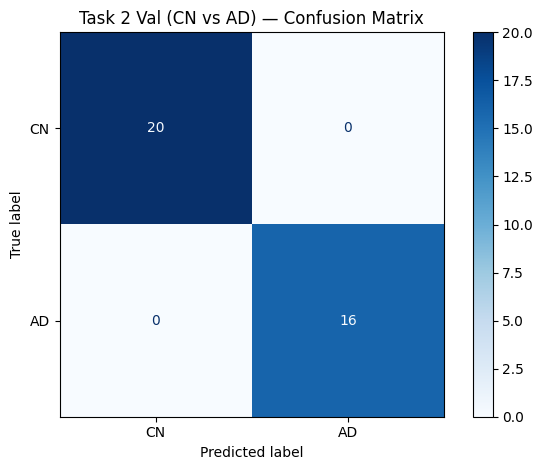


=== Task 2 Test (CN vs AD) ===
Balanced Accuracy : 0.7100
AUC               : 0.8100
Macro F1-Score    : 0.7184
Precision         : 0.7710
Recall            : 0.7100


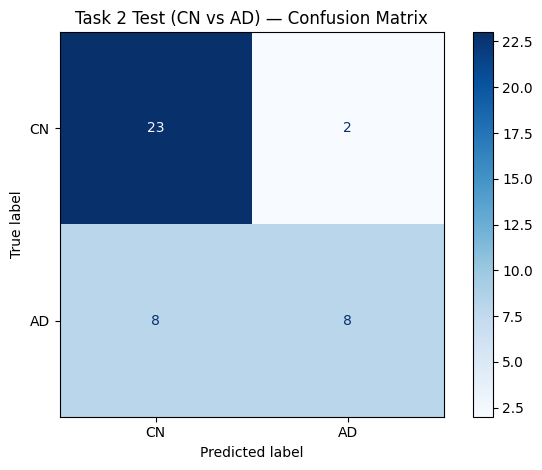


✅ Binary models saved to Google Drive
   3d_resnet10_binary.pth      → fine-tuned 3D backbone weights
   3d_pca_svm_binary_cn_ad.pkl → PCA + SVM classifier


In [18]:
# =============================================================================
# CELL 11 — Binary Classification: CN vs AD
# 3D ResNet10 → 512-dim features → PCA(64) → SVM
# =============================================================================
# Binary Classification: CN vs AD
# 3D ResNet10 → 512-dim features → PCA(64) → SVM
# =============================================================================

print("=" * 60)
print("🚀 Task 2: Binary Classification — CN vs AD")
print("   Backbone : MONAI ResNet10 (3D)")
print("   AMP      : ON  |  Batch size: 2  |  Epochs: 15")
print("=" * 60)

binary_classes = ['CN', 'AD']

# ── Datasets ──────────────────────────────────────────────────────────────────
b_train_aug_ds = MRIDataset3D(f'{OUTPUT_DIR}/train', binary_classes, augment=True)
b_train_ds     = MRIDataset3D(f'{OUTPUT_DIR}/train', binary_classes, augment=False)
b_val_ds       = MRIDataset3D(f'{OUTPUT_DIR}/val',   binary_classes, augment=False)
b_test_ds      = MRIDataset3D(f'{OUTPUT_DIR}/test',  binary_classes, augment=False)

print(f"\nDataset sizes → Train: {len(b_train_ds)} | Val: {len(b_val_ds)} | Test: {len(b_test_ds)}")

# ── DataLoaders ───────────────────────────────────────────────────────────────
# batch_size=2 is the safe ceiling for [1, 128, 128, 128] volumes on T4 16GB.
# pin_memory=True speeds up CPU→GPU transfers at this small batch size.
b_train_aug_loader = DataLoader(b_train_aug_ds, batch_size=2, shuffle=True,
                                num_workers=2, pin_memory=True)
b_train_loader     = DataLoader(b_train_ds,     batch_size=2, shuffle=False,
                                num_workers=2, pin_memory=True)
b_val_loader       = DataLoader(b_val_ds,       batch_size=2, shuffle=False,
                                num_workers=2, pin_memory=True)
b_test_loader      = DataLoader(b_test_ds,      batch_size=2, shuffle=False,
                                num_workers=2, pin_memory=True)

# ── Step 1: Fine-tune 3D backbone ─────────────────────────────────────────────
print("\n⏳ Step 1: Fine-tuning MONAI ResNet10 (3D) on binary MRI data...")
binary_model = get_3d_model(num_classes=2)
binary_model = finetune_3d_backbone(
    binary_model,
    train_loader=b_train_aug_loader,
    val_loader=b_val_loader,
    num_epochs=15,
    lr=3e-4
)

# ── Step 2: Extract 512-dim 3D features ──────────────────────────────────────
print("\n⏳ Step 2: Extracting 512-dim 3D features (AMP ON)...")
X_train_b, y_train_b = extract_features_3d(binary_model, b_train_loader)
X_val_b,   y_val_b   = extract_features_3d(binary_model, b_val_loader)
X_test_b,  y_test_b  = extract_features_3d(binary_model, b_test_loader)
X_tv_b = np.concatenate([X_train_b, X_val_b])
y_tv_b = np.concatenate([y_train_b, y_val_b])
print(f"✅ Feature shapes → Train: {X_train_b.shape} | Val: {X_val_b.shape} | Test: {X_test_b.shape}")

# ── Step 3: PCA(64) + SVM with GridSearchCV ───────────────────────────────────
print("\n⏳ Step 3: PCA(64) + SVM GridSearchCV (5-fold StratifiedKFold)...")
best_params_b, best_cv_b = train_pca_svm(X_train_b, y_train_b, n_components=64)

# Retrain final SVM on train + val combined
final_pipeline_b = build_final_svm(X_tv_b, y_tv_b, best_params_b, n_components=64)

# ── Step 4: Evaluate ──────────────────────────────────────────────────────────
evaluate_svm(
    final_pipeline_b, X_val_b, y_val_b,
    num_classes=2, task_name="Task 2 Val (CN vs AD)",
    class_names=binary_classes
)
evaluate_svm(
    final_pipeline_b, X_test_b, y_test_b,
    num_classes=2, task_name="Task 2 Test (CN vs AD)",
    class_names=binary_classes
)

# ── Save ──────────────────────────────────────────────────────────────────────
joblib.dump(final_pipeline_b, '/content/drive/MyDrive/3d_pca_svm_binary_cn_ad.pkl')
torch.save(binary_model.state_dict(), '/content/drive/MyDrive/3d_resnet10_binary.pth')
print("\n✅ Binary models saved to Google Drive")
print("   3d_resnet10_binary.pth      → fine-tuned 3D backbone weights")
print("   3d_pca_svm_binary_cn_ad.pkl → PCA + SVM classifier")

🚀 Task 3: Multiclass Classification — CN vs MCI vs AD
   Backbone : MONAI ResNet10 (3D)
   AMP      : ON  |  Batch size: 2  |  Epochs: 15

Dataset sizes → Train: 263 | Val: 61 | Test: 59

⏳ Step 1: Fine-tuning MONAI ResNet10 (3D) on multiclass MRI data...
  Epoch 01/15 — Loss: 1.1008 | Val Acc: 0.4098
  Epoch 02/15 — Loss: 1.0879 | Val Acc: 0.4098
  Epoch 03/15 — Loss: 1.0577 | Val Acc: 0.4098
  Epoch 04/15 — Loss: 1.0642 | Val Acc: 0.3115
  Epoch 05/15 — Loss: 1.0585 | Val Acc: 0.4098
  Epoch 06/15 — Loss: 1.0562 | Val Acc: 0.4098
  Epoch 07/15 — Loss: 1.1240 | Val Acc: 0.4098
  Epoch 08/15 — Loss: 1.0600 | Val Acc: 0.4098
  Epoch 09/15 — Loss: 1.0881 | Val Acc: 0.4098
  Epoch 10/15 — Loss: 1.0311 | Val Acc: 0.4262
  Epoch 11/15 — Loss: 1.0358 | Val Acc: 0.4098
  Epoch 12/15 — Loss: 1.0119 | Val Acc: 0.4262
  Epoch 13/15 — Loss: 1.0077 | Val Acc: 0.3770
  Epoch 14/15 — Loss: 1.0082 | Val Acc: 0.3770
  Epoch 15/15 — Loss: 1.0175 | Val Acc: 0.3770
✅ Fine-tuning complete. Best Val Acc: 0

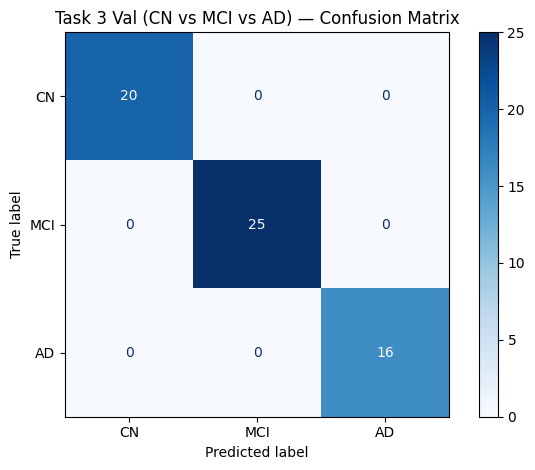


=== Task 3 Test (CN vs MCI vs AD) ===
Balanced Accuracy : 0.5843
AUC               : 0.7848
Macro F1-Score    : 0.5756
Precision         : 0.6187
Recall            : 0.5843


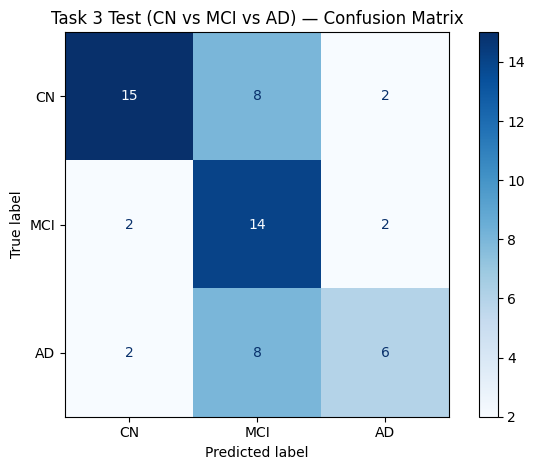


✅ Multiclass models saved to Google Drive
   3d_resnet10_multiclass.pth           → fine-tuned 3D backbone weights
   3d_pca_svm_multiclass_cn_mci_ad.pkl  → PCA + SVM classifier

🏁 All tasks complete.


In [19]:
# =============================================================================
# CELL 12 — Multiclass Classification: CN vs MCI vs AD
# 3D ResNet10 → 512-dim features → PCA(64) → SVM
#
# ⚠️  MCI NOTE: MCI is the hardest class to separate — it sits between CN and
# AD on the disease spectrum. Expect MCI recall to be lower than CN/AD.
# class_weight='balanced' in the SVM already compensates for any imbalance,
# but do not be surprised if MCI confusion is high regardless.
# =============================================================================
# Multiclass Classification: CN vs MCI vs AD
# 3D ResNet10 → 512-dim features → PCA(64) → SVM
#
# ⚠️  MCI NOTE: MCI is the hardest class to separate — it sits between CN and
# AD on the disease spectrum. Expect MCI recall to be lower than CN/AD.
# class_weight='balanced' in the SVM already compensates for any imbalance,
# but do not be surprised if MCI confusion is high regardless.
# =============================================================================

print("=" * 60)
print("🚀 Task 3: Multiclass Classification — CN vs MCI vs AD")
print("   Backbone : MONAI ResNet10 (3D)")
print("   AMP      : ON  |  Batch size: 2  |  Epochs: 15")
print("=" * 60)

multi_classes = ['CN', 'MCI', 'AD']

# ── Datasets ──────────────────────────────────────────────────────────────────
m_train_aug_ds = MRIDataset3D(f'{OUTPUT_DIR}/train', multi_classes, augment=True)
m_train_ds     = MRIDataset3D(f'{OUTPUT_DIR}/train', multi_classes, augment=False)
m_val_ds       = MRIDataset3D(f'{OUTPUT_DIR}/val',   multi_classes, augment=False)
m_test_ds      = MRIDataset3D(f'{OUTPUT_DIR}/test',  multi_classes, augment=False)

print(f"\nDataset sizes → Train: {len(m_train_ds)} | Val: {len(m_val_ds)} | Test: {len(m_test_ds)}")

# ── DataLoaders ───────────────────────────────────────────────────────────────
m_train_aug_loader = DataLoader(m_train_aug_ds, batch_size=2, shuffle=True,
                                num_workers=2, pin_memory=True)
m_train_loader     = DataLoader(m_train_ds,     batch_size=2, shuffle=False,
                                num_workers=2, pin_memory=True)
m_val_loader       = DataLoader(m_val_ds,       batch_size=2, shuffle=False,
                                num_workers=2, pin_memory=True)
m_test_loader      = DataLoader(m_test_ds,      batch_size=2, shuffle=False,
                                num_workers=2, pin_memory=True)

# ── Step 1: Fine-tune a separate 3D backbone for multiclass ───────────────────
# We train a new backbone from scratch for 3 classes.
# Do NOT reuse the binary backbone weights — the final FC has a different shape.
print("\n⏳ Step 1: Fine-tuning MONAI ResNet10 (3D) on multiclass MRI data...")
multi_model = get_3d_model(num_classes=3)
multi_model = finetune_3d_backbone(
    multi_model,
    train_loader=m_train_aug_loader,
    val_loader=m_val_loader,
    num_epochs=15,
    lr=3e-4
)

# ── Step 2: Extract 512-dim 3D features ──────────────────────────────────────
print("\n⏳ Step 2: Extracting 512-dim 3D features (AMP ON)...")
X_train_m, y_train_m = extract_features_3d(multi_model, m_train_loader)
X_val_m,   y_val_m   = extract_features_3d(multi_model, m_val_loader)
X_test_m,  y_test_m  = extract_features_3d(multi_model, m_test_loader)
X_tv_m = np.concatenate([X_train_m, X_val_m])
y_tv_m = np.concatenate([y_train_m, y_val_m])
print(f"✅ Feature shapes → Train: {X_train_m.shape} | Val: {X_val_m.shape} | Test: {X_test_m.shape}")

# ── Step 3: PCA(64) + SVM with GridSearchCV ───────────────────────────────────
print("\n⏳ Step 3: PCA(64) + SVM GridSearchCV (5-fold StratifiedKFold)...")
best_params_m, best_cv_m = train_pca_svm(X_train_m, y_train_m, n_components=64)

final_pipeline_m = build_final_svm(X_tv_m, y_tv_m, best_params_m, n_components=64)

# ── Step 4: Evaluate ──────────────────────────────────────────────────────────
evaluate_svm(
    final_pipeline_m, X_val_m, y_val_m,
    num_classes=3, task_name="Task 3 Val (CN vs MCI vs AD)",
    class_names=multi_classes
)
evaluate_svm(
    final_pipeline_m, X_test_m, y_test_m,
    num_classes=3, task_name="Task 3 Test (CN vs MCI vs AD)",
    class_names=multi_classes
)

# ── Save ──────────────────────────────────────────────────────────────────────
joblib.dump(final_pipeline_m, '/content/drive/MyDrive/3d_pca_svm_multiclass_cn_mci_ad.pkl')
torch.save(multi_model.state_dict(), '/content/drive/MyDrive/3d_resnet10_multiclass.pth')
print("\n✅ Multiclass models saved to Google Drive")
print("   3d_resnet10_multiclass.pth           → fine-tuned 3D backbone weights")
print("   3d_pca_svm_multiclass_cn_mci_ad.pkl  → PCA + SVM classifier")
print("\n🏁 All tasks complete.")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

📊  CerebroAI — Evaluation Report (Test Results)

⏳ Computing test metrics for all tasks...
✅ Metrics ready

── Binary Classification Report (Test) ──────────────────────
              precision    recall  f1-score   support

          CN       0.74      0.92      0.82        25
          AD       0.80      0.50      0.62        16

    accuracy                           0.76        41
   macro avg       0.77      0.71      0.72        41
weighted avg       0.76      0.76      0.74        41

── Multiclass Classification Report (Test) ───────────────────
              precision    recall  f1-score   support

          CN       0.79      0.60      0.68        25
         MCI       0.47      0.78      0.58        18
          AD       0.60      0.38      0.46        16

    accuracy                           0.59        59
   macro avg       0.62      0.58      0.58        59
weighted avg       0.64      0.59      0.59        59

⏳ Rendering figures...



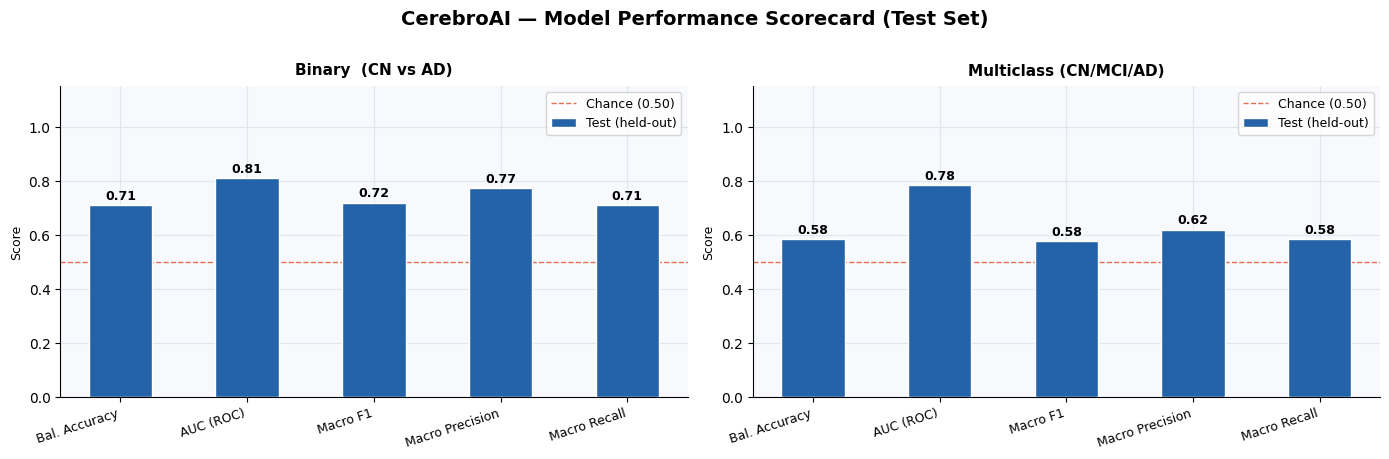

✅ Fig 1/8 — Scorecard


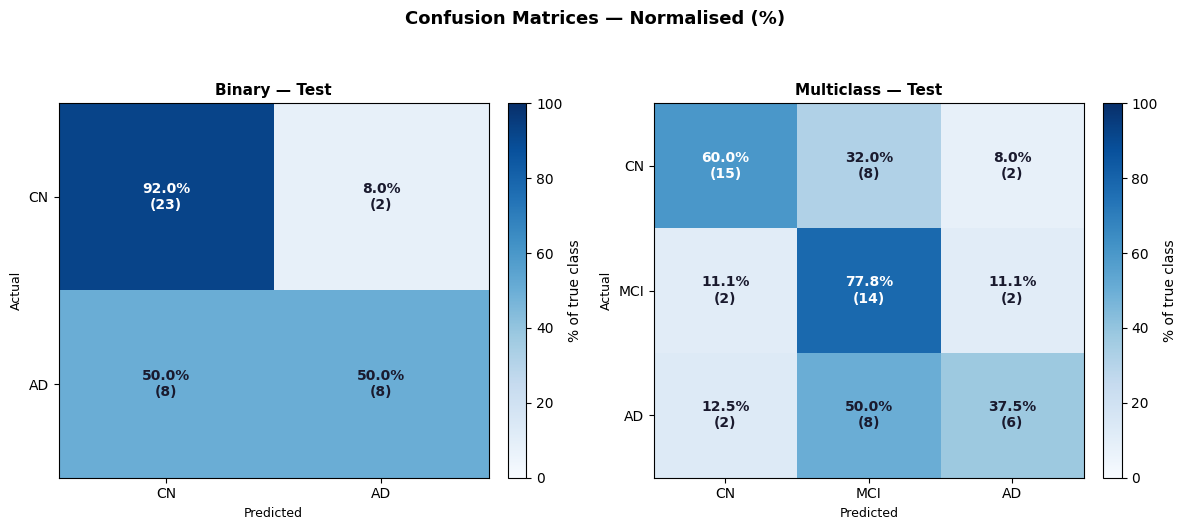

✅ Fig 2/8 — Confusion Matrices


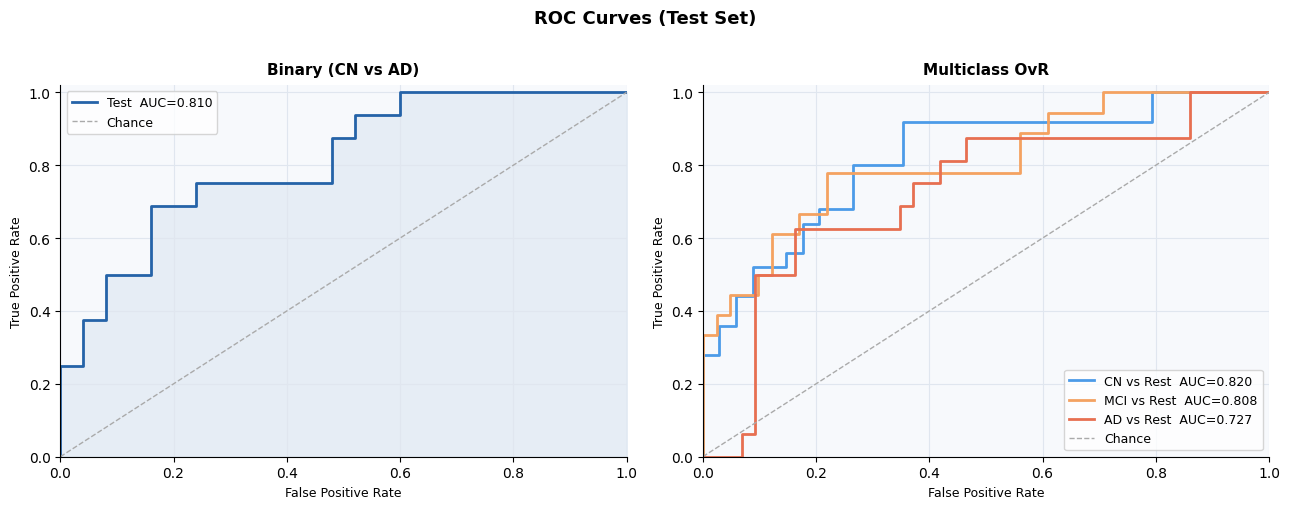

✅ Fig 3/8 — ROC Curves


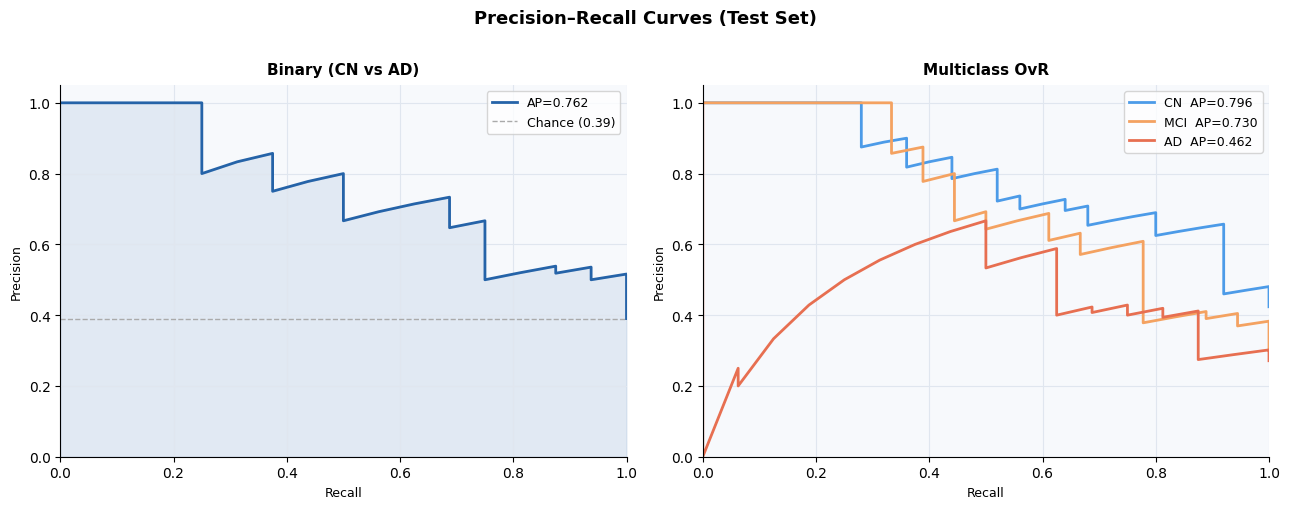

✅ Fig 4/8 — Precision-Recall Curves


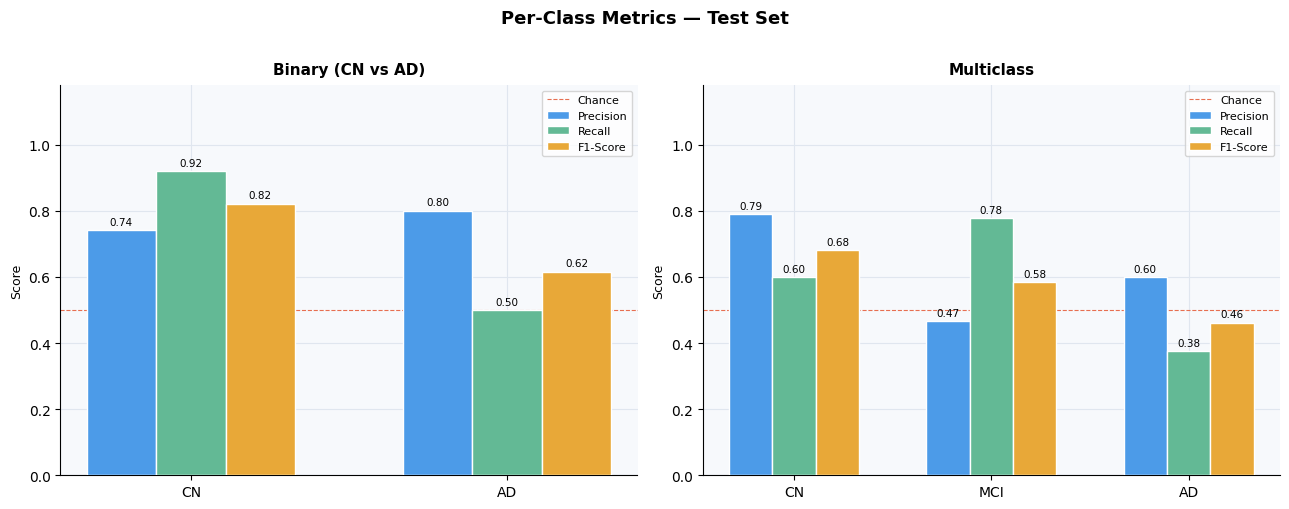

✅ Fig 5/8 — Per-Class Metrics


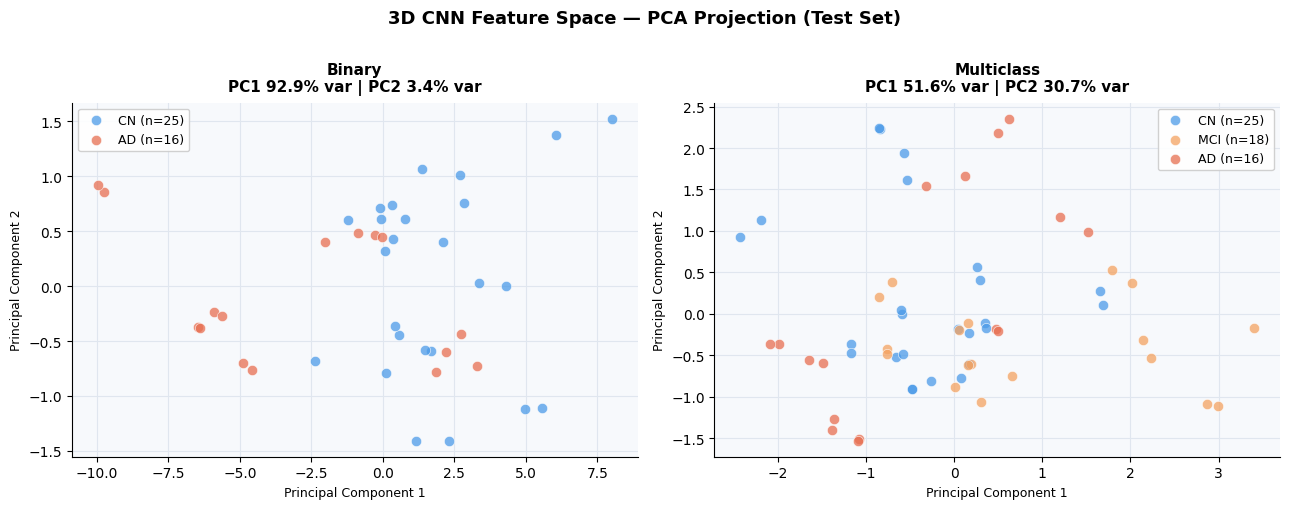

✅ Fig 6/8 — Feature Space (PCA 2D)


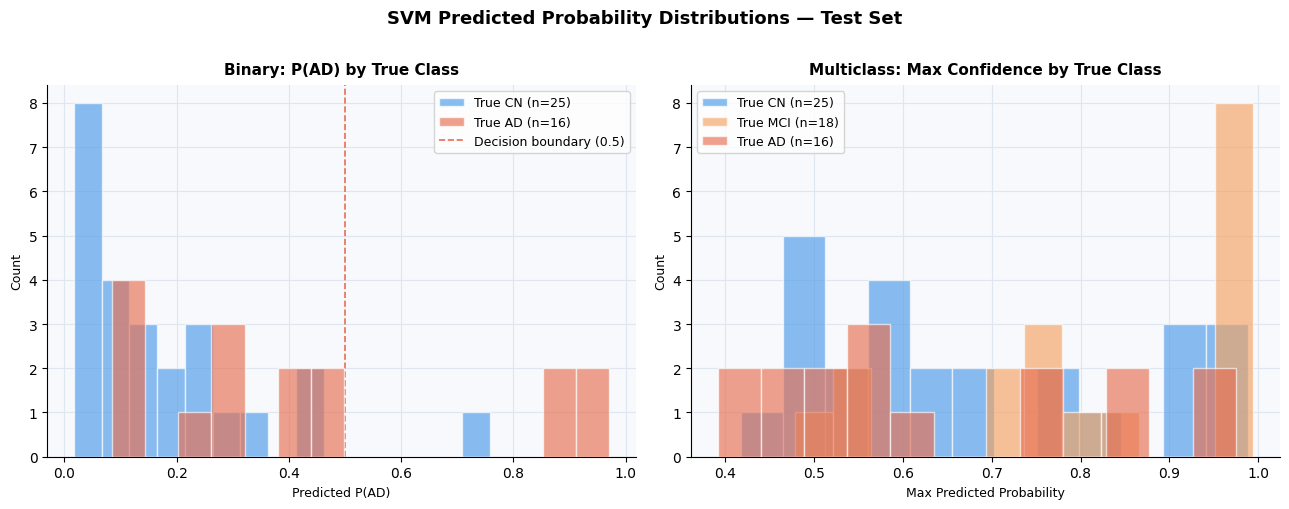

✅ Fig 7/8 — Probability Distributions


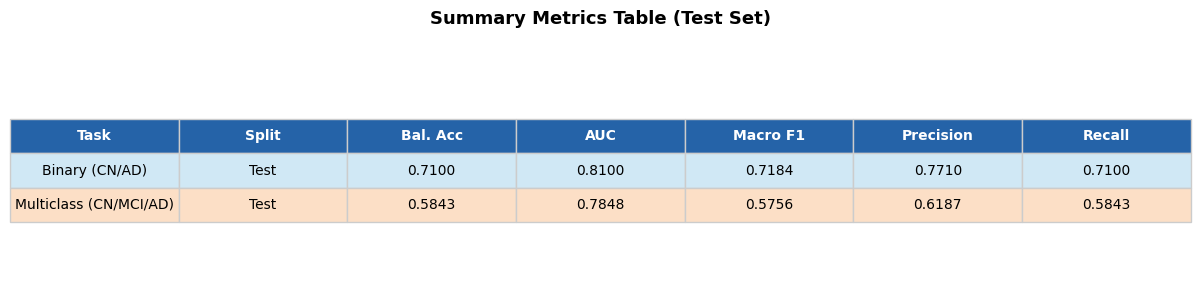

✅ Fig 8/8 — Summary Table

⏳ Saving PDF report → /content/drive/MyDrive/CerebroAI_Evaluation_Report_Test.pdf
✅ PDF saved: /content/drive/MyDrive/CerebroAI_Evaluation_Report_Test.pdf

📋 Report contents:
   Fig 1 — Scorecard: test metrics for both tasks
   Fig 2 — Confusion Matrices: normalised % with raw counts
   Fig 3 — ROC Curves: binary + multiclass OvR per class
   Fig 4 — Precision-Recall Curves: with Average Precision scores
   Fig 5 — Per-Class Metrics: precision / recall / F1 per class
   Fig 6 — Feature Space: 2D PCA projection of 512-dim 3D CNN features
   Fig 7 — Probability Distributions: confidence calibration check
   Fig 8 — Summary Table: scalar test metrics in one place


In [23]:
# =============================================================================
# CELL 13 — Comprehensive Performance Evaluation Report (Test Set Only)
# Generates all metrics + visualizations for both binary and multiclass tasks.
#
# Prerequisites: Cells 11 and 12 must have been run first. This cell reads:
#   final_pipeline_b  → binary SVM pipeline    (CN vs AD)
#   final_pipeline_m  → multiclass SVM pipeline (CN vs MCI vs AD)
#   X_test_b, y_test_b
#   X_test_m, y_test_m
#
# Output: One saved PDF report to Google Drive +
#         all plots rendered inline in the notebook.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import matplotlib.ticker as mticker
from matplotlib.backends.backend_pdf import PdfPages

from sklearn.metrics import (
    balanced_accuracy_score, roc_auc_score,
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

# ─── Palette ──────────────────────────────────────────────────────────────────
C_CN  = "#4C9BE8"   # blue
C_MCI = "#F4A261"   # orange
C_AD  = "#E76F51"   # red
C_BG  = "#F7F9FC"
C_GRID= "#E0E6EF"
PALETTE = [C_CN, C_AD]          # binary
PALETTE3= [C_CN, C_MCI, C_AD]   # multiclass

REPORT_PATH = '/content/drive/MyDrive/CerebroAI_Evaluation_Report_Test.pdf'


# =============================================================================
# Helper utilities
# =============================================================================

def full_metrics(pipeline, X, y, num_classes):
    """Return a dict of all scalar metrics for a fitted pipeline."""
    preds = pipeline.predict(X)
    probs = pipeline.predict_proba(X)
    auc   = (roc_auc_score(y, probs[:, 1])
             if num_classes == 2
             else roc_auc_score(y, probs, multi_class='ovr'))
    return {
        'preds'    : preds,
        'probs'    : probs,
        'bal_acc'  : balanced_accuracy_score(y, preds),
        'auc'      : auc,
        'macro_f1' : f1_score(y, preds, average='macro'),
        'precision': precision_score(y, preds, average='macro', zero_division=0),
        'recall'   : recall_score(y, preds, average='macro', zero_division=0),
        'cm'       : confusion_matrix(y, preds),
        'report'   : classification_report(y, preds, output_dict=True, zero_division=0),
    }


def styled_ax(ax, title='', xlabel='', ylabel=''):
    ax.set_facecolor(C_BG)
    ax.grid(True, color=C_GRID, linewidth=0.8, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)
    if title:  ax.set_title(title,  fontsize=11, fontweight='bold', pad=8)
    if xlabel: ax.set_xlabel(xlabel, fontsize=9)
    if ylabel: ax.set_ylabel(ylabel, fontsize=9)


# =============================================================================
# Figure 1 — Summary scorecard (both tasks, test only)
# =============================================================================

def fig_scorecard(b_test_m, m_test_m):
    tasks = [
        ("Binary  (CN vs AD)",         b_test_m),
        ("Multiclass (CN/MCI/AD)",      m_test_m),
    ]
    metrics_keys  = ['bal_acc', 'auc', 'macro_f1', 'precision', 'recall']
    metrics_labels= ['Bal. Accuracy', 'AUC (ROC)', 'Macro F1', 'Macro Precision', 'Macro Recall']

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), facecolor='white')
    fig.suptitle("CerebroAI — Model Performance Scorecard (Test Set)", fontsize=14,
                 fontweight='bold', y=1.01)

    bar_w = 0.5
    x     = np.arange(len(metrics_keys))

    for ax, (task_name, tm) in zip(axes, tasks):
        test_vals = [tm[k] for k in metrics_keys]

        b = ax.bar(x, test_vals, bar_w, label='Test (held-out)',
                   color='#2563A8', edgecolor='white', zorder=3)

        # Value labels on bars
        for bar in b:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

        ax.set_xticks(x)
        ax.set_xticklabels(metrics_labels, rotation=18, ha='right', fontsize=9)
        ax.set_ylim(0, 1.15)
        ax.axhline(0.5, color='#E76F51', linestyle='--', linewidth=1,
                   label='Chance (0.50)', zorder=2)
        styled_ax(ax, title=task_name, ylabel='Score')
        ax.legend(fontsize=9, loc='upper right')

    plt.tight_layout()
    return fig


# =============================================================================
# Figure 2 — Confusion Matrices (normalised %) — test for both tasks
# =============================================================================

def fig_confusion_matrices(b_test_m, m_test_m, binary_classes, multi_classes):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor='white')
    fig.suptitle("Confusion Matrices — Normalised (%)", fontsize=13,
                 fontweight='bold', y=1.05)

    configs = [
        (axes[0], b_test_m['cm'], binary_classes, "Binary — Test", PALETTE),
        (axes[1], m_test_m['cm'], multi_classes,  "Multiclass — Test", PALETTE3),
    ]

    for ax, cm, classes, title, palette in configs:
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
        n = len(classes)
        im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=100, aspect='auto')

        for i in range(n):
            for j in range(n):
                raw  = cm[i, j]
                pct  = cm_norm[i, j]
                color= 'white' if pct > 55 else '#1A1A2E'
                ax.text(j, i, f'{pct:.1f}%\n({raw})',
                        ha='center', va='center',
                        fontsize=10, fontweight='bold', color=color)

        ax.set_xticks(range(n)); ax.set_xticklabels(classes, fontsize=10)
        ax.set_yticks(range(n)); ax.set_yticklabels(classes, fontsize=10, rotation=0)
        ax.set_xlabel("Predicted", fontsize=9)
        ax.set_ylabel("Actual",    fontsize=9)
        ax.set_title(title, fontsize=11, fontweight='bold', pad=6)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                     label='% of true class')

    plt.tight_layout()
    return fig


# =============================================================================
# Figure 3 — ROC Curves
# =============================================================================

def fig_roc_curves(b_test_m, m_test_m, y_test_b, y_test_m, binary_classes, multi_classes):

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')
    fig.suptitle("ROC Curves (Test Set)", fontsize=13, fontweight='bold', y=1.01)

    # ── Binary ────────────────────────────────────────────────────────────────
    ax = axes[0]
    fpr, tpr, _ = roc_curve(y_test_b, b_test_m['probs'][:, 1])
    ax.plot(fpr, tpr, '-', linewidth=2,
            label=f'Test  AUC={b_test_m["auc"]:.3f}', color='#2563A8')

    ax.plot([0,1],[0,1],'--', color='#AAAAAA', linewidth=1, label='Chance')
    ax.fill_between(fpr, tpr, alpha=0.08, color='#2563A8')
    styled_ax(ax, title='Binary (CN vs AD)', xlabel='False Positive Rate',
              ylabel='True Positive Rate')
    ax.legend(fontsize=9); ax.set_xlim(0,1); ax.set_ylim(0,1.02)

    # ── Multiclass (OvR) ──────────────────────────────────────────────────────
    ax = axes[1]
    colors = [C_CN, C_MCI, C_AD]
    for i, cls in enumerate(multi_classes):
        y_bin = (y_test_m == i).astype(int)
        fpr, tpr, _ = roc_curve(y_bin, m_test_m['probs'][:, i])
        auc_cls = roc_auc_score(y_bin, m_test_m['probs'][:, i])
        ax.plot(fpr, tpr, '-', linewidth=2, color=colors[i],
                label=f'{cls} vs Rest  AUC={auc_cls:.3f}')

    ax.plot([0,1],[0,1],'--', color='#AAAAAA', linewidth=1, label='Chance')
    styled_ax(ax, title='Multiclass OvR',
              xlabel='False Positive Rate', ylabel='True Positive Rate')
    ax.legend(fontsize=9); ax.set_xlim(0,1); ax.set_ylim(0,1.02)

    plt.tight_layout()
    return fig


# =============================================================================
# Figure 4 — Precision-Recall Curves
# =============================================================================

def fig_pr_curves(b_test_m, m_test_m, y_test_b, y_test_m, binary_classes, multi_classes):

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')
    fig.suptitle("Precision–Recall Curves (Test Set)", fontsize=13,
                 fontweight='bold', y=1.01)

    # ── Binary ────────────────────────────────────────────────────────────────
    ax = axes[0]
    prec, rec, _ = precision_recall_curve(y_test_b, b_test_m['probs'][:, 1])
    ap = average_precision_score(y_test_b, b_test_m['probs'][:, 1])
    ax.plot(rec, prec, '-', linewidth=2, color='#2563A8', label=f'AP={ap:.3f}')
    ax.fill_between(rec, prec, alpha=0.1, color='#2563A8')
    chance = y_test_b.mean()
    ax.axhline(chance, color='#AAAAAA', linestyle='--', linewidth=1,
               label=f'Chance ({chance:.2f})')
    styled_ax(ax, title='Binary (CN vs AD)',
              xlabel='Recall', ylabel='Precision')
    ax.legend(fontsize=9); ax.set_xlim(0,1); ax.set_ylim(0,1.05)

    # ── Multiclass (OvR) ──────────────────────────────────────────────────────
    ax = axes[1]
    colors = [C_CN, C_MCI, C_AD]
    for i, cls in enumerate(multi_classes):
        y_bin = (y_test_m == i).astype(int)
        prec, rec, _ = precision_recall_curve(y_bin, m_test_m['probs'][:, i])
        ap = average_precision_score(y_bin, m_test_m['probs'][:, i])
        ax.plot(rec, prec, '-', linewidth=2, color=colors[i],
                label=f'{cls}  AP={ap:.3f}')

    styled_ax(ax, title='Multiclass OvR',
              xlabel='Recall', ylabel='Precision')
    ax.legend(fontsize=9); ax.set_xlim(0,1); ax.set_ylim(0,1.05)

    plt.tight_layout()
    return fig


# =============================================================================
# Figure 5 — Per-class metrics breakdown (bar chart)
# =============================================================================

def fig_per_class(b_test_m, m_test_m, binary_classes, multi_classes):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')
    fig.suptitle("Per-Class Metrics — Test Set", fontsize=13,
                 fontweight='bold', y=1.01)

    for ax, m, classes, palette, title in [
        (axes[0], b_test_m, binary_classes, PALETTE,  "Binary (CN vs AD)"),
        (axes[1], m_test_m, multi_classes,  PALETTE3, "Multiclass"),
    ]:
        report   = m['report']
        metrics  = ['precision', 'recall', 'f1-score']
        x        = np.arange(len(classes))
        bar_w    = 0.22
        offsets  = [-bar_w, 0, bar_w]
        labels   = ['Precision', 'Recall', 'F1-Score']
        colors   = ['#4C9BE8', '#63B995', '#E8A838']

        for k, (metric, offset, color, lbl) in enumerate(
                zip(metrics, offsets, colors, labels)):
            vals = [report[str(i)][metric] for i in range(len(classes))]
            bars = ax.bar(x + offset, vals, bar_w,
                          label=lbl, color=color, edgecolor='white', zorder=3)
            for bar in bars:
                h = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                        f'{h:.2f}', ha='center', va='bottom', fontsize=7.5)

        ax.set_xticks(x)
        ax.set_xticklabels(classes, fontsize=10)
        ax.set_ylim(0, 1.18)
        ax.axhline(0.5, color='#E76F51', linestyle='--', linewidth=0.8,
                   label='Chance', zorder=2)
        styled_ax(ax, title=title, ylabel='Score')
        ax.legend(fontsize=8, loc='upper right')

    plt.tight_layout()
    return fig


# =============================================================================
# Figure 6 — PCA feature-space visualisation (2D projection of 512-dim feats)
# =============================================================================

def fig_feature_space(X_test_b, y_test_b, X_test_m, y_test_m,
                      binary_classes, multi_classes):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')
    fig.suptitle("3D CNN Feature Space — PCA Projection (Test Set)",
                 fontsize=13, fontweight='bold', y=1.01)

    configs = [
        (axes[0], X_test_b, y_test_b, binary_classes, PALETTE,  "Binary"),
        (axes[1], X_test_m, y_test_m, multi_classes,  PALETTE3, "Multiclass"),
    ]

    for ax, X, y, classes, palette, title in configs:
        pca2 = PCA(n_components=2, random_state=42)
        X2   = pca2.fit_transform(X)
        var  = pca2.explained_variance_ratio_

        for i, (cls, color) in enumerate(zip(classes, palette)):
            mask = y == i
            ax.scatter(X2[mask, 0], X2[mask, 1],
                       c=color, label=f'{cls} (n={mask.sum()})',
                       alpha=0.75, s=55, edgecolors='white', linewidths=0.5,
                       zorder=3)

        styled_ax(ax,
                  title=f'{title}\nPC1 {var[0]*100:.1f}% var | PC2 {var[1]*100:.1f}% var',
                  xlabel='Principal Component 1',
                  ylabel='Principal Component 2')
        ax.legend(fontsize=9, framealpha=0.9)

    plt.tight_layout()
    return fig


# =============================================================================
# Figure 7 — SVM decision probability distribution (calibration check)
# =============================================================================

def fig_prob_distribution(b_test_m, m_test_m,
                           y_test_b, y_test_m,
                           binary_classes, multi_classes):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')
    fig.suptitle("SVM Predicted Probability Distributions — Test Set",
                 fontsize=13, fontweight='bold', y=1.01)

    # Binary: histogram of P(AD) per true class
    ax = axes[0]
    for i, (cls, color) in enumerate(zip(binary_classes, PALETTE)):
        mask = y_test_b == i
        ax.hist(b_test_m['probs'][mask, 1], bins=15,
                alpha=0.65, color=color, edgecolor='white',
                label=f'True {cls} (n={mask.sum()})', zorder=3)
    ax.axvline(0.5, color='#E76F51', linestyle='--', linewidth=1.2,
               label='Decision boundary (0.5)')
    styled_ax(ax, title='Binary: P(AD) by True Class',
              xlabel='Predicted P(AD)', ylabel='Count')
    ax.legend(fontsize=9)

    # Multiclass: max-probability (confidence) by true class
    ax = axes[1]
    max_probs = m_test_m['probs'].max(axis=1)
    for i, (cls, color) in enumerate(zip(multi_classes, PALETTE3)):
        mask = y_test_m == i
        ax.hist(max_probs[mask], bins=12,
                alpha=0.65, color=color, edgecolor='white',
                label=f'True {cls} (n={mask.sum()})', zorder=3)
    styled_ax(ax, title='Multiclass: Max Confidence by True Class',
              xlabel='Max Predicted Probability', ylabel='Count')
    ax.legend(fontsize=9)

    plt.tight_layout()
    return fig


# =============================================================================
# Figure 8 — Plain-text summary table
# =============================================================================

def fig_summary_table(b_test_m, m_test_m):
    fig, ax = plt.subplots(figsize=(12, 3), facecolor='white')
    ax.axis('off')
    fig.suptitle("Summary Metrics Table (Test Set)", fontsize=13,
                 fontweight='bold', y=0.98)

    col_labels = ['Task', 'Split', 'Bal. Acc', 'AUC', 'Macro F1',
                  'Precision', 'Recall']
    rows = [
        ["Binary (CN/AD)",          "Test",
         f'{b_test_m["bal_acc"]:.4f}',f'{b_test_m["auc"]:.4f}',
         f'{b_test_m["macro_f1"]:.4f}',f'{b_test_m["precision"]:.4f}',
         f'{b_test_m["recall"]:.4f}'],
        ["Multiclass (CN/MCI/AD)",  "Test",
         f'{m_test_m["bal_acc"]:.4f}',f'{m_test_m["auc"]:.4f}',
         f'{m_test_m["macro_f1"]:.4f}',f'{m_test_m["precision"]:.4f}',
         f'{m_test_m["recall"]:.4f}'],
    ]

    row_colors = [
        ['#D0E8F5']*7,
        ['#FCDFC6']*7,
    ]

    tbl = ax.table(
        cellText=rows,
        colLabels=col_labels,
        cellLoc='center',
        loc='center',
        cellColours=row_colors,
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1.2, 2.0)

    for (r, c), cell in tbl.get_celld().items():
        cell.set_edgecolor('#CCCCCC')
        if r == 0:
            cell.set_facecolor('#2563A8')
            cell.set_text_props(color='white', fontweight='bold')

    plt.tight_layout()
    return fig


# =============================================================================
# MAIN — compute all metrics then render all figures
# =============================================================================

print("=" * 62)
print("📊  CerebroAI — Evaluation Report (Test Results)")
print("=" * 62)

# ── Compute all metrics ───────────────────────────────────────────────────────
print("\n⏳ Computing test metrics for all tasks...")

b_test_m = full_metrics(final_pipeline_b, X_test_b, y_test_b, num_classes=2)
m_test_m = full_metrics(final_pipeline_m, X_test_m, y_test_m, num_classes=3)

print("✅ Metrics ready\n")

# ── Print classification reports to console ───────────────────────────────────
from sklearn.metrics import classification_report
print("── Binary Classification Report (Test) ──────────────────────")
print(classification_report(y_test_b, b_test_m['preds'],
                             target_names=binary_classes, zero_division=0))
print("── Multiclass Classification Report (Test) ───────────────────")
print(classification_report(y_test_m, m_test_m['preds'],
                             target_names=multi_classes, zero_division=0))

# ── Render figures inline ─────────────────────────────────────────────────────
print("⏳ Rendering figures...\n")

f1  = fig_scorecard(b_test_m, m_test_m)
plt.show(); print("✅ Fig 1/8 — Scorecard")

f2  = fig_confusion_matrices(b_test_m, m_test_m,
                              binary_classes, multi_classes)
plt.show(); print("✅ Fig 2/8 — Confusion Matrices")

f3  = fig_roc_curves(b_test_m, m_test_m,
                     y_test_b, y_test_m,
                     binary_classes, multi_classes)
plt.show(); print("✅ Fig 3/8 — ROC Curves")

f4  = fig_pr_curves(b_test_m, m_test_m, y_test_b, y_test_m,
                    binary_classes, multi_classes)
plt.show(); print("✅ Fig 4/8 — Precision-Recall Curves")

f5  = fig_per_class(b_test_m, m_test_m, binary_classes, multi_classes)
plt.show(); print("✅ Fig 5/8 — Per-Class Metrics")

f6  = fig_feature_space(X_test_b, y_test_b, X_test_m, y_test_m,
                        binary_classes, multi_classes)
plt.show(); print("✅ Fig 6/8 — Feature Space (PCA 2D)")

f7  = fig_prob_distribution(b_test_m, m_test_m, y_test_b, y_test_m,
                             binary_classes, multi_classes)
plt.show(); print("✅ Fig 7/8 — Probability Distributions")

f8  = fig_summary_table(b_test_m, m_test_m)
plt.show(); print("✅ Fig 8/8 — Summary Table")

# ── Save all figures to a single PDF on Google Drive ─────────────────────────
print(f"\n⏳ Saving PDF report → {REPORT_PATH}")
with PdfPages(REPORT_PATH) as pdf:
    for fig_obj in [f1, f2, f3, f4, f5, f6, f7, f8]:
        pdf.savefig(fig_obj, bbox_inches='tight', facecolor='white')
        plt.close(fig_obj)

    # PDF metadata
    d = pdf.infodict()
    d['Title']   = 'CerebroAI — Alzheimer Classification Evaluation Report (Test)'
    d['Author']  = 'CerebroAI Pipeline'
    d['Subject'] = 'Binary & Multiclass MRI Classification — MONAI ResNet10 + PCA + SVM'

print(f"✅ PDF saved: {REPORT_PATH}")
print("\n📋 Report contents:")
print("   Fig 1 — Scorecard: test metrics for both tasks")
print("   Fig 2 — Confusion Matrices: normalised % with raw counts")
print("   Fig 3 — ROC Curves: binary + multiclass OvR per class")
print("   Fig 4 — Precision-Recall Curves: with Average Precision scores")
print("   Fig 5 — Per-Class Metrics: precision / recall / F1 per class")
print("   Fig 6 — Feature Space: 2D PCA projection of 512-dim 3D CNN features")
print("   Fig 7 — Probability Distributions: confidence calibration check")
print("   Fig 8 — Summary Table: scalar test metrics in one place")